# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 91.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 53.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 87.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


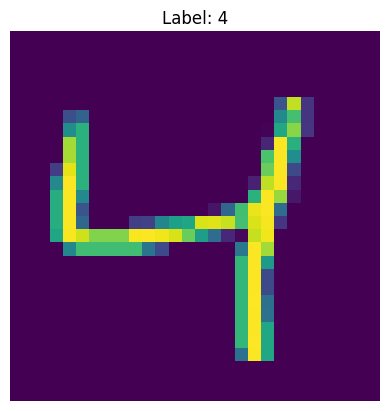

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [6]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [7]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지을 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.12786412239074707  Accuracy: 96.14710998535156 %
Iteration: 1000  Loss: 0.04404362291097641  Accuracy: 97.21735382080078 %
Iteration: 1500  Loss: 0.04412988945841789  Accuracy: 97.50924682617188 %
Iteration: 2000  Loss: 0.027316173538565636  Accuracy: 97.7232894897461 %
Iteration: 2500  Loss: 0.03991709649562836  Accuracy: 97.87896728515625 %
Iteration: 3000  Loss: 0.060002200305461884  Accuracy: 98.03463745117188 %
Iteration: 3500  Loss: 0.054502058774232864  Accuracy: 98.26814270019531 %
Iteration: 4000  Loss: 0.0792689174413681  Accuracy: 98.36544036865234 %
Iteration: 4500  Loss: 0.011616280302405357  Accuracy: 98.5794906616211 %


#### **ANN 학습 결과**

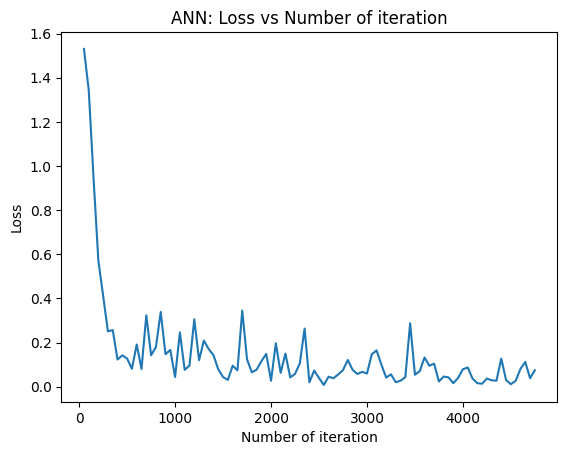

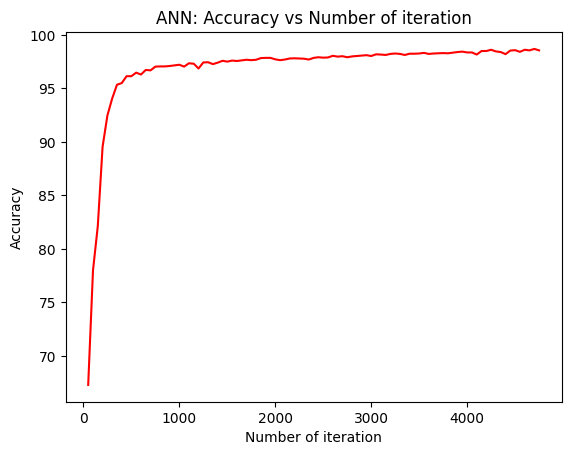

In [8]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗

* * *
## **[해석]**
- 반복 횟수가 증가함에 따라 손실은 감소하고 정확도는 증가하는 것을 확인할 수 있습니다. 즉, 학습 데이터를 통해 점진적으로 성능이 향상되고 있음을 보여줍니다.

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗

* * *
## **[답변]**
- ANN: ANN은 이미지와 같은 2D 데이터를 처리하기 위해서는 입력 데이터를 1D 벡터로 펼쳐야 합니다. MNIST 데이터셋에서 ANN은 숫자를 분류하는 데 사용되었으며, 학습 결과 Loss가 감소하고 Accuracy가 증가하는 것을 확인할 수 있습니다.

- CNN: 합성곱 계층과 풀링 계층을 사용하여 이미지의 특징을 효과적으로 추출하며, 공간적인 정보를 보존합니다. MNIST 데이터셋에서 CNN은 ANN보다 더 높은 정확도를 보입니다. 시각화된 결과를 보면 CNN이 ANN보다 Loss가 더 빠르게 감소하고 Accuracy가 더 높게 수렴하는 것을 확인할 수 있습니다.

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗

* * *
## **[답변]**
- Learning Rate는 모델이 학습 과정에서 가중치를 얼마나 크게 업데이트할지를 결정하는 값입니다. Learning Rate가 너무 크면 학습이 불안정해지고 최적값을 찾지 못하고 발산할 수 있습니다. 반대로 Learning Rate가 너무 작으면 학습 속도가 매우 느려지고 로컬 미니멈에 갇힐 수 있습니다. 시각화된 결과에서 Learning Rate가 0.02일 때 Loss가 비교적 안정적으로 감소하고 Accuracy가 높게 나타나는 것을 확인할 수 있습니다.

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗

* * *
## **[답변]**
- Hidden Dimension 값은 모델의 복잡성을 결정합니다. Hidden Dimension이 작으면 모델의 표현력이 낮아 복잡한 패턴을 학습하기 어려울 수 있습니다. 반대로 Hidden Dimension이 너무 크면 모델이 과적합될 가능성이 높아지고 학습 시간이 오래 걸릴 수 있습니다. 시각화된 결과에서 Hidden Dimension이 150일 때 Loss 감소 폭이 안정적이고 Accuracy가 비교적 높게 나타나는 것을 확인할 수 있습니다.

In [9]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import matplotlib.pyplot as plt

hidden_dims_to_test = [50, 100, 150, 200]
ann_results = {}

for hidden_dim_val in hidden_dims_to_test:
    print(f"Training ANN with hidden_dim = {hidden_dim_val}")
    model = ANNModel(input_dim, hidden_dim_val, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []
    num_epochs_exp = 5 # Reduce epochs for faster experiment

    for epoch in range(num_epochs_exp):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for images, labels in test_loader:
                        test = images.view(-1, 28*28)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(labels)
                        correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)
        print(f"  Epoch {epoch+1}/{num_epochs_exp}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

    ann_results[hidden_dim_val] = {
        "iterations": iteration_list,
        "losses": loss_list,
        "accuracies": accuracy_list
    }

Training ANN with hidden_dim = 50
  Epoch 1/5, Loss: 0.0530, Accuracy: 95.74%
  Epoch 2/5, Loss: 0.0349, Accuracy: 97.02%
  Epoch 3/5, Loss: 0.0171, Accuracy: 97.43%
  Epoch 4/5, Loss: 0.0191, Accuracy: 97.59%
  Epoch 5/5, Loss: 0.0150, Accuracy: 97.96%
Training ANN with hidden_dim = 100
  Epoch 1/5, Loss: 0.1225, Accuracy: 96.09%
  Epoch 2/5, Loss: 0.0088, Accuracy: 97.10%
  Epoch 3/5, Loss: 0.0110, Accuracy: 97.26%
  Epoch 4/5, Loss: 0.0284, Accuracy: 97.63%
  Epoch 5/5, Loss: 0.0203, Accuracy: 97.84%
Training ANN with hidden_dim = 150
  Epoch 1/5, Loss: 0.1435, Accuracy: 95.93%
  Epoch 2/5, Loss: 0.0033, Accuracy: 97.14%
  Epoch 3/5, Loss: 0.0111, Accuracy: 97.33%
  Epoch 4/5, Loss: 0.0156, Accuracy: 97.59%
  Epoch 5/5, Loss: 0.0052, Accuracy: 97.70%
Training ANN with hidden_dim = 200
  Epoch 1/5, Loss: 0.1454, Accuracy: 96.17%
  Epoch 2/5, Loss: 0.0634, Accuracy: 97.18%
  Epoch 3/5, Loss: 0.3718, Accuracy: 97.33%
  Epoch 4/5, Loss: 0.2685, Accuracy: 97.70%
  Epoch 5/5, Loss: 0.0200

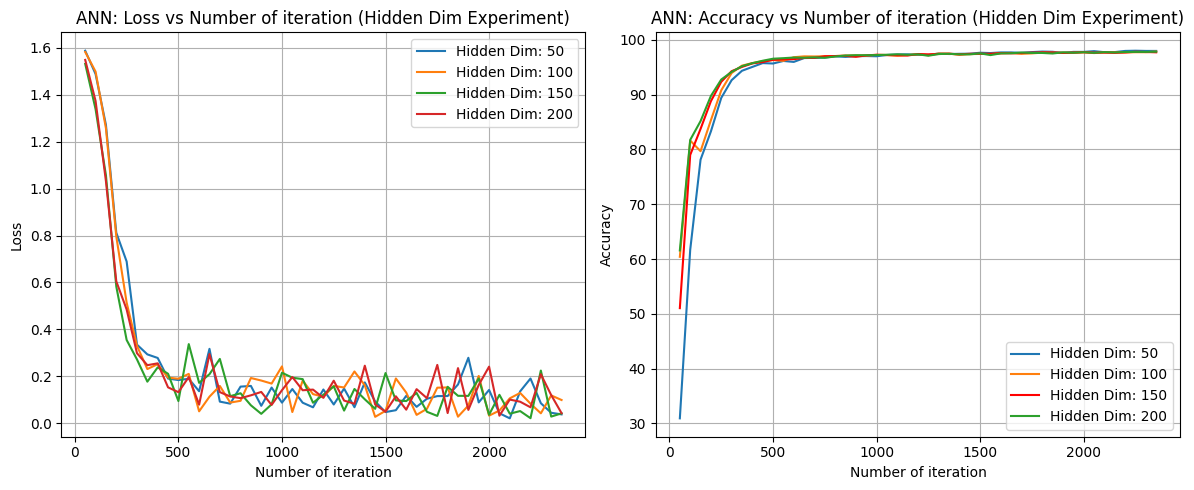

In [10]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(12, 5))

# Loss 시각화
plt.subplot(1, 2, 1)
for hidden_dim_val, results in ann_results.items():
    plt.plot(results["iterations"], results["losses"], label=f'Hidden Dim: {hidden_dim_val}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (Hidden Dim Experiment)")
plt.legend()
plt.grid(True)

# Accuracy 시각화
plt.subplot(1, 2, 2)
for hidden_dim_val, results in ann_results.items():
    plt.plot(results["iterations"], results["accuracies"], label=f'Hidden Dim: {hidden_dim_val}', color = "red" if hidden_dim_val==150 else None) # Highlight default 150
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (Hidden Dim Experiment)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗

* * *
## **[답변]**
- Hidden Dimension 값은 모델의 복잡성을 결정합니다. Hidden Dimension이 작으면 모델의 표현력이 낮아 복잡한 패턴을 학습하기 어려울 수 있습니다. 반대로 Hidden Dimension이 너무 크면 모델이 과적합될 가능성이 높아지고 학습 시간이 오래 걸릴 수 있습니다. 시각화된 결과에서 Hidden Dimension이 150일 때 Loss 감소 폭이 안정적이고 Accuracy가 비교적 높게 나타나는 것을 확인할 수 있습니다.

In [11]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
import matplotlib.pyplot as plt

learning_rates_to_test = [0.1, 0.05, 0.02, 0.01, 0.005]
ann_lr_results = {}
hidden_dim_opt = 150 # Use the default or best hidden_dim from experiment 1

for lr_val in learning_rates_to_test:
    print(f"Training ANN with learning_rate = {lr_val}")
    model = ANNModel(input_dim, hidden_dim_opt, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr_val)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []
    num_epochs_exp = 5 # Reduce epochs for faster experiment

    for epoch in range(num_epochs_exp):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for images, labels in test_loader:
                        test = images.view(-1, 28*28)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(labels)
                        correct += (predicted == labels).sum()
                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)
        print(f"  Epoch {epoch+1}/{num_epochs_exp}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

    ann_lr_results[lr_val] = {
        "iterations": iteration_list,
        "losses": loss_list,
        "accuracies": accuracy_list
    }

Training ANN with learning_rate = 0.1
  Epoch 1/5, Loss: 0.0081, Accuracy: 97.18%
  Epoch 2/5, Loss: 0.0765, Accuracy: 98.19%
  Epoch 3/5, Loss: 0.0003, Accuracy: 98.48%
  Epoch 4/5, Loss: 0.0023, Accuracy: 98.85%
  Epoch 5/5, Loss: 0.0037, Accuracy: 99.18%
Training ANN with learning_rate = 0.05
  Epoch 1/5, Loss: 0.0125, Accuracy: 97.26%
  Epoch 2/5, Loss: 0.0238, Accuracy: 97.98%
  Epoch 3/5, Loss: 0.0055, Accuracy: 98.17%
  Epoch 4/5, Loss: 0.0050, Accuracy: 98.56%
  Epoch 5/5, Loss: 0.0167, Accuracy: 98.72%
Training ANN with learning_rate = 0.02
  Epoch 1/5, Loss: 0.3170, Accuracy: 95.97%
  Epoch 2/5, Loss: 1.5217, Accuracy: 97.14%
  Epoch 3/5, Loss: 0.6457, Accuracy: 97.47%
  Epoch 4/5, Loss: 0.0048, Accuracy: 97.59%
  Epoch 5/5, Loss: 0.0073, Accuracy: 97.78%
Training ANN with learning_rate = 0.01
  Epoch 1/5, Loss: 0.4909, Accuracy: 90.50%
  Epoch 2/5, Loss: 0.1015, Accuracy: 95.93%
  Epoch 3/5, Loss: 0.0192, Accuracy: 96.89%
  Epoch 4/5, Loss: 0.0080, Accuracy: 97.16%
  Epoch 5

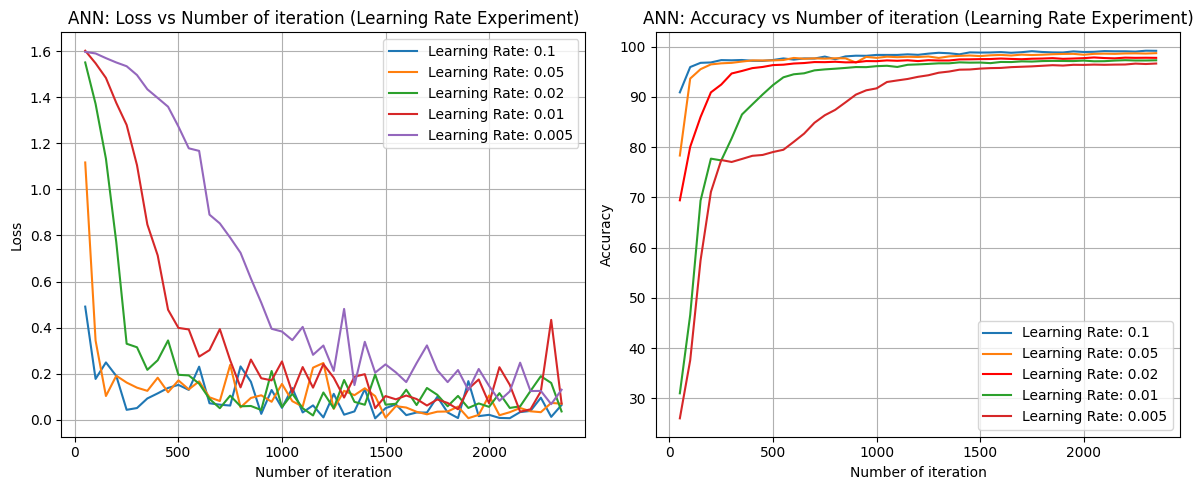

In [12]:
# 실험 2 모델 학습 결과 시각화
plt.figure(figsize=(12, 5))

# Loss 시각화
plt.subplot(1, 2, 1)
for lr_val, results in ann_lr_results.items():
    plt.plot(results["iterations"], results["losses"], label=f'Learning Rate: {lr_val}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (Learning Rate Experiment)")
plt.legend()
plt.grid(True)

# Accuracy 시각화
plt.subplot(1, 2, 2)
for lr_val, results in ann_lr_results.items():
    plt.plot(results["iterations"], results["accuracies"], label=f'Learning Rate: {lr_val}', color = "red" if lr_val==0.02 else None) # Highlight default 0.02
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (Learning Rate Experiment)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

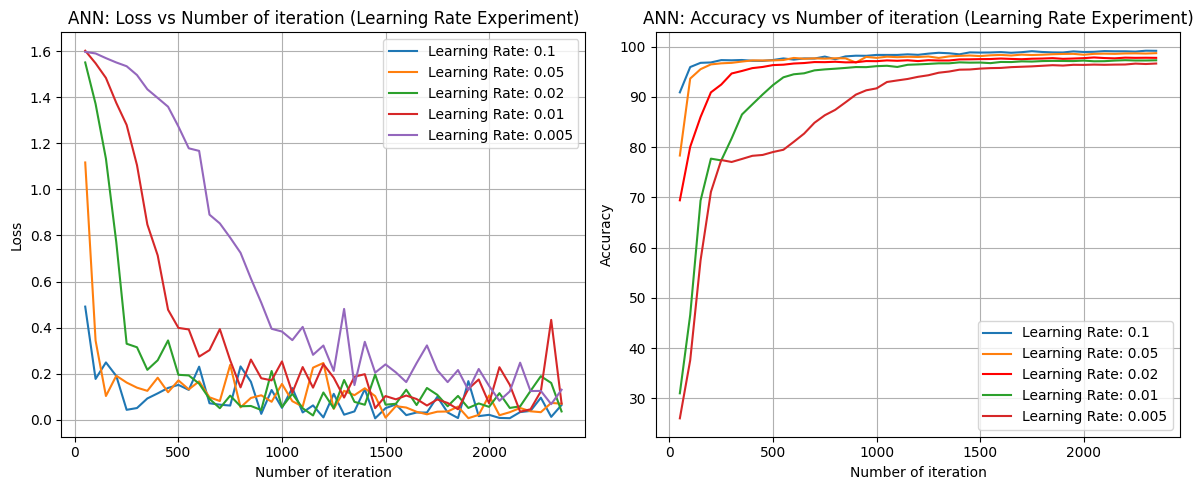

In [13]:
# 실험 2 모델 학습 결과 시각화
plt.figure(figsize=(12, 5))

# Loss 시각화
plt.subplot(1, 2, 1)
for lr_val, results in ann_lr_results.items():
    plt.plot(results["iterations"], results["losses"], label=f'Learning Rate: {lr_val}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (Learning Rate Experiment)")
plt.legend()
plt.grid(True)

# Accuracy 시각화
plt.subplot(1, 2, 2)
for lr_val, results in ann_lr_results.items():
    plt.plot(results["iterations"], results["accuracies"], label=f'Learning Rate: {lr_val}', color = "red" if lr_val==0.02 else None) # Highlight default 0.02
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (Learning Rate Experiment)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗

* * *
## **[답변]**
- Learning Rate는 모델이 학습 과정에서 가중치를 얼마나 크게 업데이트할지를 결정하는 값입니다. Learning Rate가 너무 크면 학습이 불안정해지고 최적값을 찾지 못하고 발산할 수 있습니다. 반대로 Learning Rate가 너무 작으면 학습 속도가 매우 느려지고 로컬 미니멈에 갇힐 수 있습니다. 시각화된 결과에서 Learning Rate가 0.02일 때 Loss가 비교적 안정적으로 감소하고 Accuracy가 높게 나타나는 것을 확인할 수 있습니다.

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗

* * *
## **[해석]**
- 시각화된 ANN 모델의 학습 결과를 보면, 반복 횟수(Number of iteration)가 증가함에 따라 손실(Loss)은 감소하고 정확도(Accuracy)는 증가하는 것을 확인할 수 있습니다. 이는 모델이 학습 데이터를 통해 점진적으로 성능이 향상되고 있음을 보여줍니다. Loss 그래프는 우하향하는 추세를 보이며, Accuracy 그래프는 우상향하는 추세를 보입니다. 이는 모델이 훈련 데이터에 잘 맞춰지고 테스트 데이터에 대한 예측 성능이 개선되고 있음을 의미합니다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out

In [15]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [16]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.49797896689313437
Epoch 2, Loss: 0.12990431255410137
Epoch 3, Loss: 0.10703616962808968
Epoch 4, Loss: 0.09225613463598076
Epoch 5, Loss: 0.08267453000229436
Epoch 6, Loss: 0.07404835533354595
Epoch 7, Loss: 0.06688998676525401
Epoch 8, Loss: 0.06016457105096282
Epoch 9, Loss: 0.05522081852425862
Epoch 10, Loss: 0.05095978737137979
Epoch 11, Loss: 0.04717069724017596
Epoch 12, Loss: 0.04370189679685459
Epoch 13, Loss: 0.041554215303884666
Epoch 14, Loss: 0.03897463169924931
Epoch 15, Loss: 0.037011130391143746
Epoch 16, Loss: 0.03514538854428631
Epoch 17, Loss: 0.03354139832803097
Epoch 18, Loss: 0.03166138750378486
Epoch 19, Loss: 0.031090905102667845
Epoch 20, Loss: 0.030185728673414874


#### **CNN 학습 결과**

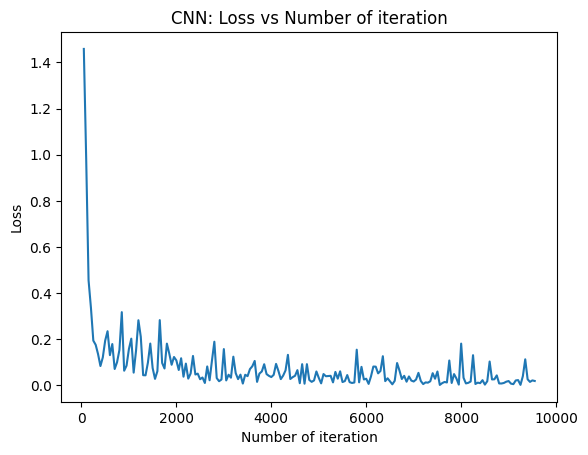

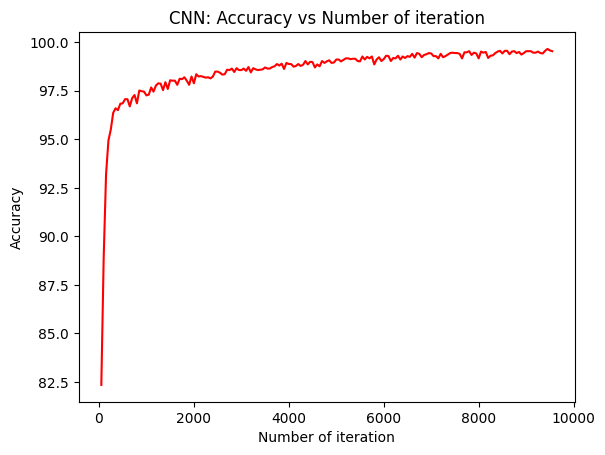

In [17]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗

* * *
## **[답변]**
- **ANN (Artificial Neural Network)**: ANN은 입력, 은닉, 출력 계층으로 구성된 기본적인 신경망입니다. 각 계층의 뉴런들은 서로 완전히 연결되어 있으며, 이미지와 같은 2D 데이터를 처리하기 위해서는 입력 데이터를 1D 벡터로 펼쳐야 합니다. MNIST 데이터셋에서 ANN은 숫자를 분류하는 데 사용되었으며, 학습 결과 Loss가 감소하고 Accuracy가 증가하는 것을 확인할 수 있습니다. 하지만 이미지를 펼치는 과정에서 공간적인 정보가 손실될 수 있습니다.

- **CNN (Convolutional Neural Network)**: CNN은 이미지 처리와 같은 격자형 데이터에 특화된 신경망입니다. 합성곱 계층과 풀링 계층을 사용하여 이미지의 특징을 효과적으로 추출하며, 공간적인 정보를 보존합니다. MNIST 데이터셋에서 CNN은 ANN보다 더 높은 정확도를 달성하는 경향이 있으며, 이는 CNN이 이미지의 특징을 더 잘 학습하기 때문입니다. 시각화된 결과를 보면 CNN이 ANN보다 Loss가 더 빠르게 감소하고 Accuracy가 더 높게 수렴하는 것을 확인할 수 있습니다. 이는 CNN이 이미지 데이터의 공간적 구조를 활용하여 더 효과적인 학습을 수행함을 시사합니다.

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗

* * *
## **[해석]**
- 시각화된 CNN 모델의 학습 결과를 보면, 반복 횟수(Number of iteration)가 증가함에 따라 손실(Loss)은 감소하고 정확도(Accuracy)는 증가하는 것을 확인할 수 있습니다. ANN 모델과 비교했을 때, CNN 모델은 이미지의 공간적 특징을 더 효과적으로 학습하여 더 빠르게 Loss가 감소하고 더 높은 Accuracy에 도달하는 경향을 보입니다. 이는 CNN이 이미지 분류 작업에 더 적합함을 시사합니다.